In [1]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start')
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start/plot')
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as C
from plot.plot_basic import savefig
from plot.plot_1D import plot_multiple_1D_fields
from read_write import read_nc,read_sdf
from plot.plot_2D import generate_side_panel_axes,plot_multiple_2D_fields,plot_2D_field,plot_polar_field,plot_quiver_field

In [2]:
theta_degree=45
theta_rad=np.radians(theta_degree)

laser_lambda = 0.8*C.micron		# Laser wavelength
laser_f0=1/laser_lambda
laser_k0=2*C.pi*laser_f0
laser_omega0=(2*C.pi*C.speed_of_light)/(laser_lambda)
laser_period=laser_lambda/C.speed_of_light
laser_a0=20		# Laser field strength
laser_Bc=(C.m_e*laser_omega0)/(C.elementary_charge)
laser_Ec=laser_Bc*C.speed_of_light   #4.013376e+12V/m
laser_Sc=C.epsilon_0*C.speed_of_light*laser_Ec**2/2   #1.327e+18 W/m^2
laser_amp=laser_a0*laser_Ec
laser_FWHM=8*C.femto   #The full width at half maximum of the intensity.
laser_tau=laser_FWHM/np.sqrt(2*np.log(2)) 
#laser_tau=laser_period/jnp.sqrt(jnp.pi)
laser_Nc=laser_omega0**2*C.m_e*C.epsilon_0/C.elementary_charge**2
laser_S0=C.epsilon_0*C.speed_of_light*laser_amp**2/2   #average Poynting vector

target_N=200

cells_per_lambda =2000
vacuum_length_x_lambda=20   #lambda
continuation_length_lambda=2000   #lambda
space_length_lambda=vacuum_length_x_lambda+2*continuation_length_lambda   #lambda
n_field_x=round(vacuum_length_x_lambda*cells_per_lambda)
n_continuation_x=round(space_length_lambda*cells_per_lambda)

d_x=laser_lambda/cells_per_lambda   #unit: m
d_f=1/(space_length_lambda*laser_lambda)   #unit: 1/m, d_x*d_f=1/n_continuation_x

print('λ0/dx=',laser_lambda/d_x)
print('f0/df=',laser_f0/d_f)

laser_lambda_M=laser_lambda/np.cos(theta_rad)
laser_period_M=laser_period/np.cos(theta_rad)
laser_tau_M=laser_tau/np.cos(theta_rad)
laser_f0_M=laser_f0*np.cos(theta_rad)
laser_k0_M=laser_k0*np.cos(theta_rad)
laser_Bc_M=laser_Bc*np.cos(theta_rad)
laser_Ec_M=laser_Ec*np.cos(theta_rad)
laser_Sc_M=laser_Sc*np.cos(theta_rad)**2
laser_Nc_M=laser_Nc/np.cos(theta_rad)
laser_amp_M=laser_amp*np.cos(theta_rad)
laser_S0_M=laser_S0*np.cos(theta_rad)**2
vacuum_length_x_lambda_M=vacuum_length_x_lambda*np.cos(theta_rad)
space_length_lambda_M=space_length_lambda*np.cos(theta_rad)   #laser_f0_M/d_f

laser_spectrum_peak_M=laser_amp_M*(np.sqrt(C.pi)/2)*(laser_tau_M*C.speed_of_light)*(1-np.exp(-laser_k0_M**2*(laser_tau_M*C.speed_of_light)**2))
laser_energy_M=laser_amp_M**2*np.sqrt(C.pi/2)*(laser_tau_M*C.speed_of_light/2)*(1-np.exp(-laser_k0_M**2*(laser_tau_M*C.speed_of_light)**2/2))
laser_envelope_integral_M=laser_amp_M**2*(laser_tau_M*C.speed_of_light)*np.sqrt(C.pi/2)

plasma_cutoff_order=np.sqrt(target_N/(np.cos(theta_rad))**3)

highest_harmonic=100000

λ0/dx= 2000.0
f0/df= 4019.9999999999995


In [4]:
working_dir='/scratch/gpfs/MIKHAILOVA/zl8336/Curved_surface/a0=20/2D/K=-0.002,D=0.06,L=0.00'
data_dict=read_sdf(sdf_name=os.path.join(working_dir,'fields0005.sdf'),block_name_list=['Magnetic_Field_Bz'])

Reading file /scratch/gpfs/MIKHAILOVA/zl8336/Curved_surface/a0=20/2D/K=-0.002,D=0.06,L=0.00/fields0005.sdf
t() = time
bz(100000, 50000) = bz
ex(100000, 50000) = ex
ey(100000, 50000) = ey
x(100001, 50001) = grid
y(100001, 50001) = grid
xc(100000, 50000) = grid_mid
yc(100000, 50000) = grid_mid
x,shape=(100000,)
y,shape=(50000,)
Magnetic_Field_Bz,shape=(100000, 50000)


In [5]:
Bz=data_dict['Magnetic_Field_Bz']
x_coordinate=data_dict['x']
y_coordinate=data_dict['y']

figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)


{'fig': <Figure size 1850x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_panel_top': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='a=Bz/Bc'>,
 'ax_panel_left': <Axes: xlabel='a=Bz/Bc', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14c8844427b0>}

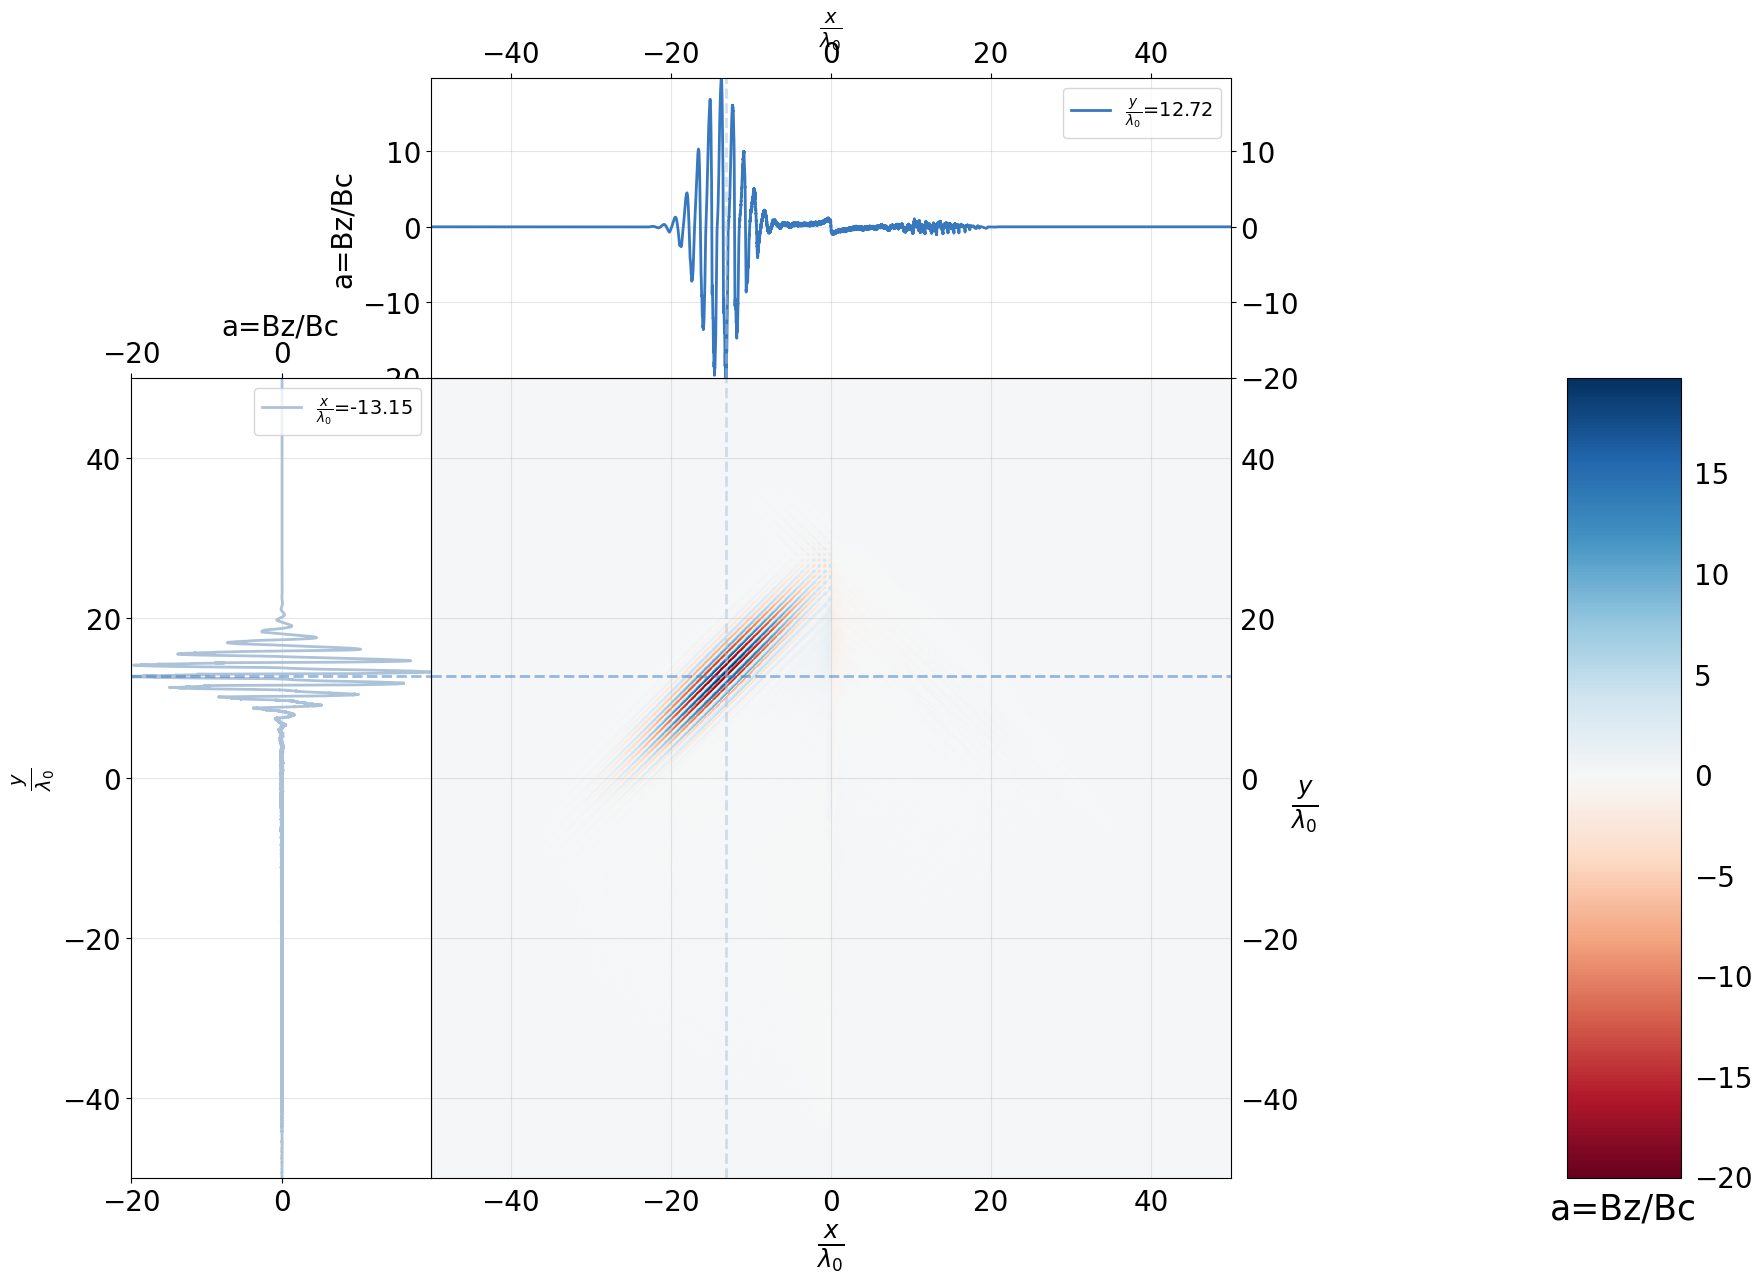

In [6]:
plot_2D_field(
    field=Bz/laser_Bc,
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=y_coordinate/laser_lambda,
    cmap='RdBu',label='a=Bz/Bc',
    step_x=40,step_y=20,
    )

In [4]:
working_dir='/scratch/gpfs/MIKHAILOVA/zl8336/Curved_surface/a0=20/2D/K=-0.010'
data_dict=read_nc(nc_name=os.path.join(working_dir,'Field_t=+20.0T0.nc.nc'),key_name_list=['Bz', 'εr'])


Read /scratch/gpfs/MIKHAILOVA/zl8336/Curved_surface/a0=20/2D/K=-0.010/Field_t=+20.0T0.nc.nc
Available keys: ['Ex', 'Ey', 'Bz', 'εr']
Coordinates:
  * x        (x) float64 22kB -3.599e-05 -3.598e-05 ... 7.976e-06 7.992e-06
  * y        (y) float64 36kB -3.599e-05 -3.598e-05 ... 3.598e-05 3.599e-05
x: <xarray.DataArray 'x' (x: 2750)> Size: 22kB
array([-3.5992e-05, -3.5976e-05, -3.5960e-05, ...,  7.9600e-06,  7.9760e-06,
        7.9920e-06], shape=(2750,))
Coordinates:
  * x        (x) float64 22kB -3.599e-05 -3.598e-05 ... 7.976e-06 7.992e-06
Attributes:
    units:      m
    long_name:  
y: <xarray.DataArray 'y' (y: 4500)> Size: 36kB
array([-3.5992e-05, -3.5976e-05, -3.5960e-05, ...,  3.5960e-05,  3.5976e-05,
        3.5992e-05], shape=(4500,))
Coordinates:
  * y        (y) float64 36kB -3.599e-05 -3.598e-05 ... 3.598e-05 3.599e-05
Attributes:
    units:      m
    long_name:  
Data variables:
    Ex       (x, y) float64 99MB ...
    Ey       (x, y) float64 99MB ...
    Bz       (x, y) 

In [5]:
Bz=data_dict['Bz']
Epsilon=data_dict['εr']
x_coordinate = data_dict['x']
y_coordinate = data_dict['y']

figure size= [15.38819738 14.        ] inch
ax_main position= Bbox(x0=0.29243191321869383, y0=0.10714285714285714, x1=0.610090782375075, y1=0.6785714285714285)


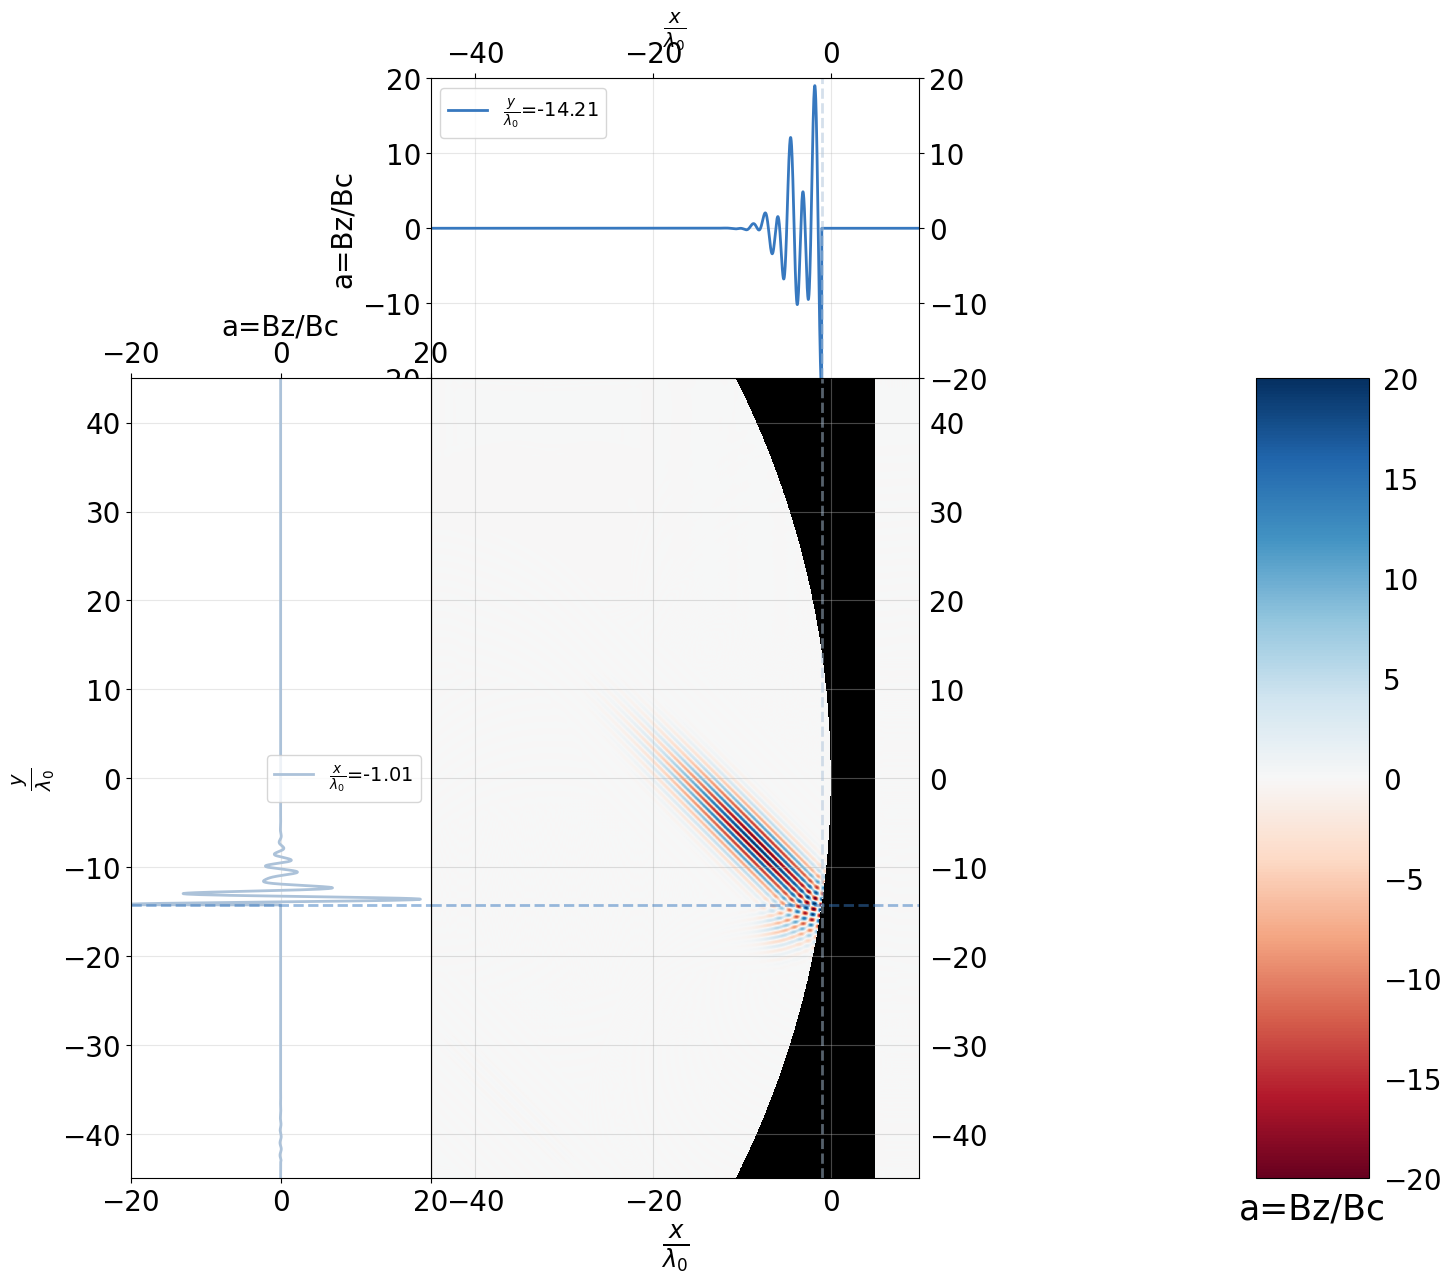

In [8]:
ax_dict=plot_2D_field(
    field=Bz/laser_Bc,
    x_coordinate=x_coordinate/laser_lambda,
    y_coordinate=y_coordinate/laser_lambda,
    cmap='RdBu',
    label='a=Bz/Bc',vmin=-20,vmax=20,
)

ax_dict=plot_2D_field(
    field=Epsilon,
    x_coordinate=x_coordinate/laser_lambda,
    y_coordinate=y_coordinate/laser_lambda,
    cmap='Greys_r',
    label='εr',vmin=-1e10,vmax=0,threshold=2,
    plot_profile_x=False,plot_profile_y=False,plot_colorbar=False,
    ax_dict=ax_dict
)



figure size= [15.38819738 14.        ] inch
ax_main position= Bbox(x0=0.29243191321869383, y0=0.10714285714285714, x1=0.610090782375075, y1=0.6785714285714285)


{'fig': <Figure size 1538.82x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_panel_top': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='εr'>,
 'ax_panel_left': <Axes: xlabel='εr', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x1547c564e190>}

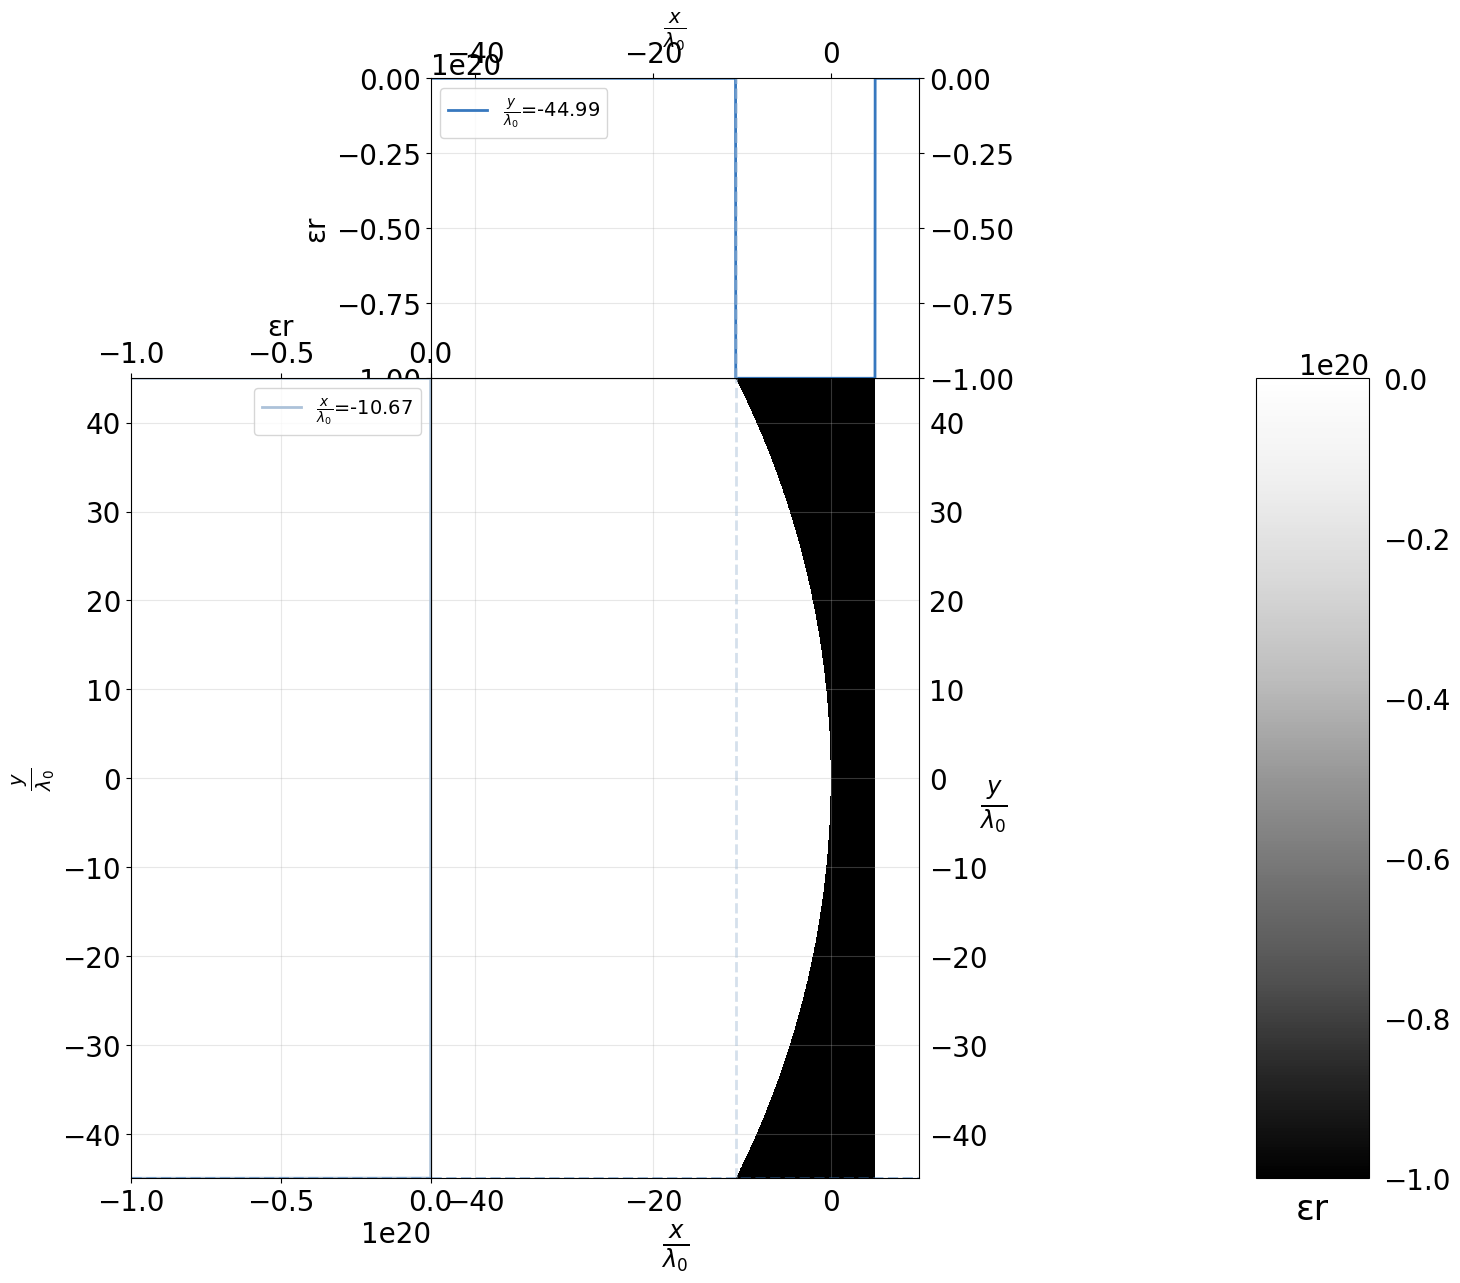

In [11]:
plot_2D_field(
    field=Epsilon,
    x_coordinate=x_coordinate/laser_lambda,
    y_coordinate=y_coordinate/laser_lambda,
    cmap='Greys_r',
    label='εr',
)